# CAA Per-Source Emotion Direction Structure

**仮説**: 感情の内部構造は「ラベル付きカテゴリ」ではなく、連続的な変化の方向によって特徴づけられる。
各ソーステキストごとに独立に計算した `h_emotion[n] - h_neutral[n]`（個別CAAベクトル）を分析することで、
- **感情方向の一貫性**: 個別CAAは全ソースで同じ方向を向くか？（一貫性が高ければ感情は安定した方向を持つ）
- **感情内部の下位構造**: 感情ごとのローカルPCAで下位軸（サブタイプ）を発見する
- **感情間の方向境界**: 個別CAAは感情間でどれだけ重複するか？

**残差ストリームとの違い**: `emotion_internal_structure.ipynb` では `h_emotion[n,e,i]` から
ソースセンタリング（`- mean_{e'} h[n,e',i]`）してから各感情のローカルPCAを行った。
本ノートブックでは `h_emotion[n,e,i] - h_neutral[n]` （= 個別CAAベクトル）を直接使うため、
ソースセンタリングの近似誤差なしに感情変化方向を解析できる。

**分析内容**:
1. 個別CAAベクトルの計算とサブサンプリング
2. 感情ごとの方向一貫性 (cos similarity with global pooled CAA)
3. 感情ごとのローカルPCA → 感情内部の変動軸
4. 参加比率と低次元性の検証
5. 感情間の個別CAAベクトルの重複 (Separability)
6. 個別CAAの2D射影と感情「コーン」の可視化

**入力**:
- `activation/emotion_rewrites/emotion_intensity_residual_stream.npy` — `(N, 8, 3, 6, D)`
- `activation/emotion_rewrites/neutral_paraphrase_residual_stream.npy` — `(N, 6, D)`
- `activation/emotion_rewrites/caa_emotion_directions.npz` — global reference CAA

**出力**: `analysis/caa/per_source_structure/`

**対応する既存ノートブック**: `emotion_internal_structure.ipynb` のCAA版


## 0. Setup

**メモリ注意**: 全活性化テンソルは `(22782, 8, 3, 6, 4096) float32 ≈ 54 GB`。
`np.memmap` とソースサブサンプリングで常に RAM < 4 GB に抑える。

In [1]:
from __future__ import annotations

import gc
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')

REPO_ROOT    = Path('../..').resolve()
ACT_DIR      = REPO_ROOT / 'activation' / 'emotion_rewrites'
EMO_NPY      = ACT_DIR / 'emotion_intensity_residual_stream.npy'
EMO_INFO     = ACT_DIR / 'emotion_intensity_residual_stream_info.json'
NEUTRAL_NPY  = ACT_DIR / 'neutral_paraphrase_residual_stream.npy'
NEUTRAL_INFO = ACT_DIR / 'neutral_paraphrase_residual_stream_info.json'
CAA_PATH     = ACT_DIR / 'caa_emotion_directions.npz'
CAA_INFO     = ACT_DIR / 'caa_emotion_directions_info.json'
OUT_DIR      = REPO_ROOT / 'analysis' / 'caa' / 'per_source_structure'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_LAYER = 13
MAX_SOURCES   = 2500   # RAM cap (~2 GB for one layer)
SEED          = 0

rng = np.random.default_rng(SEED)
sns.set_context('notebook')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150})
print('OUT_DIR =', OUT_DIR)


OUT_DIR = /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/per_source_structure


In [2]:
# Load metadata
with open(EMO_INFO)     as f: EMO_META     = json.load(f)
with open(NEUTRAL_INFO) as f: NEUTRAL_META = json.load(f)
with open(CAA_INFO)     as f: CAA_META     = json.load(f)

# Validate source_id alignment
assert EMO_META['source_ids'] == NEUTRAL_META['source_ids'], (
    "source_ids mismatch between emotion and neutral-paraphrase info files. "
    "Re-extract activations with matching source_id order."
)

EMOTION_ORDER   = EMO_META['emotion_order']
INTENSITY_ORDER = EMO_META['intensity_order']
LAYER_INDICES   = EMO_META['layer_indices']
N_EMO  = len(EMOTION_ORDER)
N_INT  = len(INTENSITY_ORDER)
LI_MAP = {l: i for i, l in enumerate(LAYER_INDICES)}
EMO_POS = {e: i for i, e in enumerate(EMOTION_ORDER)}

EMO_SHAPE     = tuple(EMO_META['shape'])        # (N, 8, 3, 6, 4096)
NEUTRAL_SHAPE = tuple(NEUTRAL_META['shape'])    # (N, 6, 4096)
N_TOTAL, _, _, N_LAY, D = EMO_SHAPE

# Memory-map both arrays — never materialize fully
ACT_EMO     = np.memmap(str(EMO_NPY),     dtype='float32', mode='r', shape=EMO_SHAPE)
ACT_NEUTRAL = np.memmap(str(NEUTRAL_NPY), dtype='float32', mode='r', shape=NEUTRAL_SHAPE)

# Stable source subsample
if N_TOTAL > MAX_SOURCES:
    SRC_IDX = np.sort(rng.choice(N_TOTAL, size=MAX_SOURCES, replace=False))
else:
    SRC_IDX = np.arange(N_TOTAL)
N_SUB = len(SRC_IDX)

# Load global CAA reference
caa_data   = np.load(CAA_PATH)
CAA_POOLED = caa_data['caa_pooled']  # (8, 6, 4096)

print(f'EMO_SHAPE     = {EMO_SHAPE}')
print(f'NEUTRAL_SHAPE = {NEUTRAL_SHAPE}')
print(f'Working on {N_SUB}/{N_TOTAL} sources.  D={D}')
print(f'Emotions: {EMOTION_ORDER}')


EMO_SHAPE     = (22782, 8, 3, 6, 4096)
NEUTRAL_SHAPE = (22782, 6, 4096)
Working on 2500/22782 sources.  D=4096
Emotions: ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']


In [3]:
# ── Helpers ───────────────────────────────────────────────────────────────────

def unit(v: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / (n + 1e-12)

def participation_ratio(s: np.ndarray) -> float:
    lam = s.astype(np.float64) ** 2
    return float(lam.sum() ** 2 / (lam ** 2).sum())

def load_per_source_caa(layer: int,
                         pool_intensity: bool = True) -> np.ndarray:
    """
    Compute per-source CAA vectors:
        delta[n, e, i, l] = h_emotion[n, e, i, l] - h_neutral[n, l]

    Uses in-place subtraction to avoid duplicating the (N_SUB, 8, 3, D)
    array (~938 MB), keeping peak RAM to ~1.3 GB instead of ~1.9 GB.

    Returns:
        If pool_intensity=True:  (N_SUB, N_EMO, D)  averaged over intensities
        If pool_intensity=False: (N_SUB, N_EMO, N_INT, D)
    """
    li = LI_MAP[layer]
    h_neutral = np.asarray(ACT_NEUTRAL[SRC_IDX, li, :], dtype=np.float32)     # (N_SUB, D) ~40 MB
    delta     = np.asarray(ACT_EMO[SRC_IDX, :, :, li, :], dtype=np.float32)   # (N_SUB, 8, 3, D) ~938 MB
    delta -= h_neutral[:, np.newaxis, np.newaxis, :]                            # in-place: no extra copy
    del h_neutral

    if pool_intensity:
        result = delta.mean(axis=2)   # (N_SUB, 8, D) ~312 MB
        del delta
        return result
    return delta

print('Helpers defined.')


Helpers defined.


---
## 1. 感情方向の一貫性 — 個別CAAはグローバル方向と揃うか？

各ソース `n` について `delta[n, e] = h_emotion[n,e] - h_neutral[n]` を計算し、
そのユニットベクトルとグローバルCAA（全ソース平均）のコサイン類似度を測定する。

- **高い一貫性** (cos ≈ 0.8–1.0): 感情方向はソース非依存の安定した軸
- **低い一貫性** (cos ≈ 0): 感情方向はソースごとに大きく異なる → 平均化に意味がない


In [4]:
li_primary = LI_MAP[PRIMARY_LAYER]
global_caa = CAA_POOLED[:, li_primary, :]  # (8, D) unit-normed

# Load per-source CAA at primary layer
print(f'Loading per-source CAA at layer {PRIMARY_LAYER} ...')
delta_pooled = load_per_source_caa(PRIMARY_LAYER, pool_intensity=True)  # (N_SUB, 8, D)
print(f'delta_pooled shape: {delta_pooled.shape}')

# Cosine similarity of each source's CAA with global direction
# unit(delta[n, e]) · global_caa[e]
delta_u = unit(delta_pooled)  # (N_SUB, 8, D)
# cos[n, e] = delta_u[n, e] · global_caa[e]
cos_with_global = np.einsum('ned,ed->ne', delta_u, global_caa)  # (N_SUB, 8)

df_cos = pd.DataFrame(cos_with_global, columns=EMOTION_ORDER)

print(f'\nPer-source CAA direction consistency with global (layer {PRIMARY_LAYER}):')
summary_cos = df_cos.describe().loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
print(summary_cos.to_string(float_format='{:.4f}'.format))

Loading per-source CAA at layer 13 ...
delta_pooled shape: (2500, 8, 4096)

Per-source CAA direction consistency with global (layer 13):
        joy  trust   fear  surprise  sadness  disgust  anger  anticipation
mean 0.8551 0.8536 0.8538    0.8555   0.8567   0.8540 0.8548        0.8570
std  0.0550 0.0542 0.0539    0.0558   0.0545   0.0548 0.0545        0.0545
min  0.5813 0.5858 0.5831    0.5575   0.5825   0.5699 0.5721        0.5838
25%  0.8292 0.8292 0.8301    0.8288   0.8309   0.8302 0.8295        0.8318
50%  0.8723 0.8706 0.8697    0.8740   0.8739   0.8708 0.8717        0.8739
75%  0.8937 0.8915 0.8914    0.8947   0.8945   0.8920 0.8932        0.8955
max  0.9324 0.9336 0.9283    0.9320   0.9363   0.9320 0.9351        0.9330


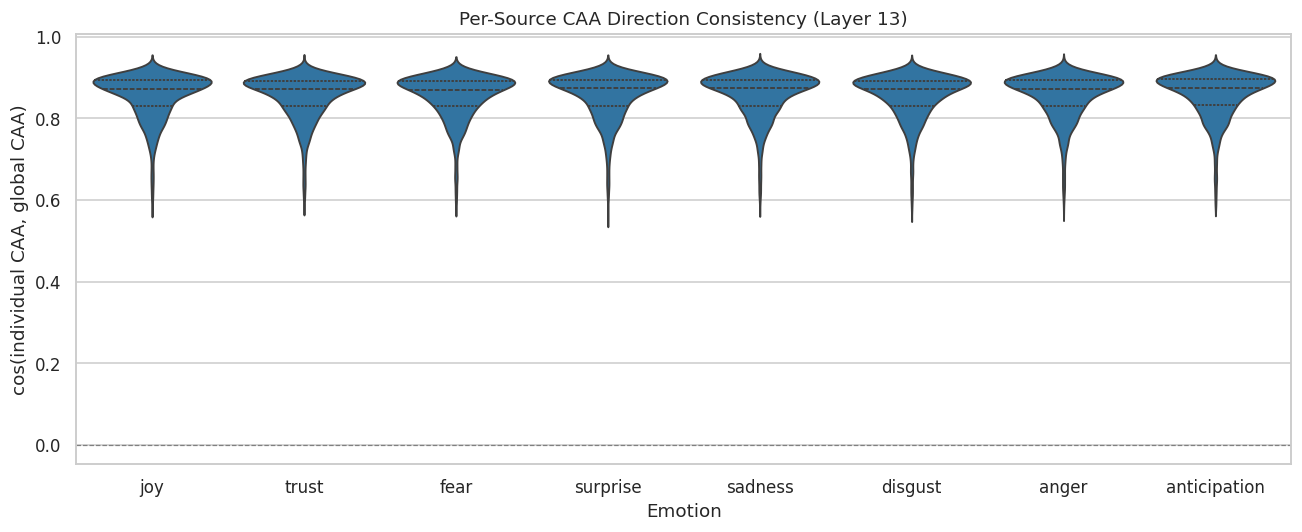

In [5]:
# Violin plot of consistency per emotion
fig, ax = plt.subplots(figsize=(12, 5))
df_melt = df_cos.melt(var_name='emotion', value_name='cosine')
sns.violinplot(data=df_melt, x='emotion', y='cosine', order=EMOTION_ORDER,
               inner='quartile', ax=ax)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Emotion')
ax.set_ylabel('cos(individual CAA, global CAA)')
ax.set_title(f'Per-Source CAA Direction Consistency (Layer {PRIMARY_LAYER})')
plt.tight_layout()
plt.savefig(OUT_DIR / f'caa_consistency_violin_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

df_cos.describe().to_csv(OUT_DIR / f'caa_consistency_summary_L{PRIMARY_LAYER}.csv')

---
## 2. 感情ごとのローカルPCA — 感情内部の変動軸

各感情 `e` の個別CAAベクトル `{delta[n, e]}_{n=1..N}` に対してPCAを行い、
感情内部の変動を特徴づける。

- **参加比率 PR ≈ 1**: 感情方向は1次元（全ソースが同じ方向を指す）→ 感情はアトミック
- **参加比率 PR ≈ 3–5**: 感情内部に複数の独立した軸が存在 → 感情にサブタイプ・連続構造

ローカルPC1はグローバルCAA方向（強度軸）と何角度をなすか？

In [6]:
K_LOCAL = 5  # local PCs to extract per emotion

rows_local = []
local_pcs  = {}  # {emotion: (K_LOCAL, D)}

for e, emo in enumerate(EMOTION_ORDER):
    X = delta_pooled[:, e, :]  # (N_SUB, D)
    mu = X.mean(axis=0)
    Xc = X - mu

    pca = PCA(n_components=K_LOCAL, random_state=SEED)
    pca.fit(Xc)
    evr   = pca.explained_variance_ratio_
    s     = np.sqrt(pca.explained_variance_)  # singular values proxy
    pr    = participation_ratio(s)
    local_pcs[emo] = pca.components_  # (K_LOCAL, D)

    # Alignment of local PC1 with global CAA
    pc1  = pca.components_[0]           # (D,)
    gcaa = global_caa[e]                 # (D,)
    cos_pc1_gcaa = abs(float(unit(pc1) @ unit(gcaa)))

    rows_local.append({
        'emotion': emo,
        'PR': pr,
        'EVR_PC1': evr[0],
        'EVR_PC1-2': evr[:2].sum(),
        'EVR_PC1-3': evr[:3].sum(),
        'cos_PC1_globalCAA': cos_pc1_gcaa,
    })

df_local = pd.DataFrame(rows_local).set_index('emotion')
print(f'Local PCA results at layer {PRIMARY_LAYER}:')
print(df_local.to_string(float_format='{:.4f}'.format))
df_local.to_csv(OUT_DIR / f'caa_local_pca_L{PRIMARY_LAYER}.csv')

Local PCA results at layer 13:
                 PR  EVR_PC1  EVR_PC1-2  EVR_PC1-3  cos_PC1_globalCAA
emotion                                                              
joy          3.6117   0.1224     0.1804     0.2197             0.2520
trust        3.5609   0.1179     0.1747     0.2131             0.2539
fear         3.6037   0.1157     0.1717     0.2096             0.2564
surprise     3.5431   0.1217     0.1796     0.2180             0.2534
sadness      3.6908   0.1176     0.1750     0.2137             0.2583
disgust      3.7339   0.1149     0.1717     0.2108             0.2525
anger        3.6808   0.1159     0.1727     0.2117             0.2575
anticipation 3.5900   0.1187     0.1764     0.2150             0.2498


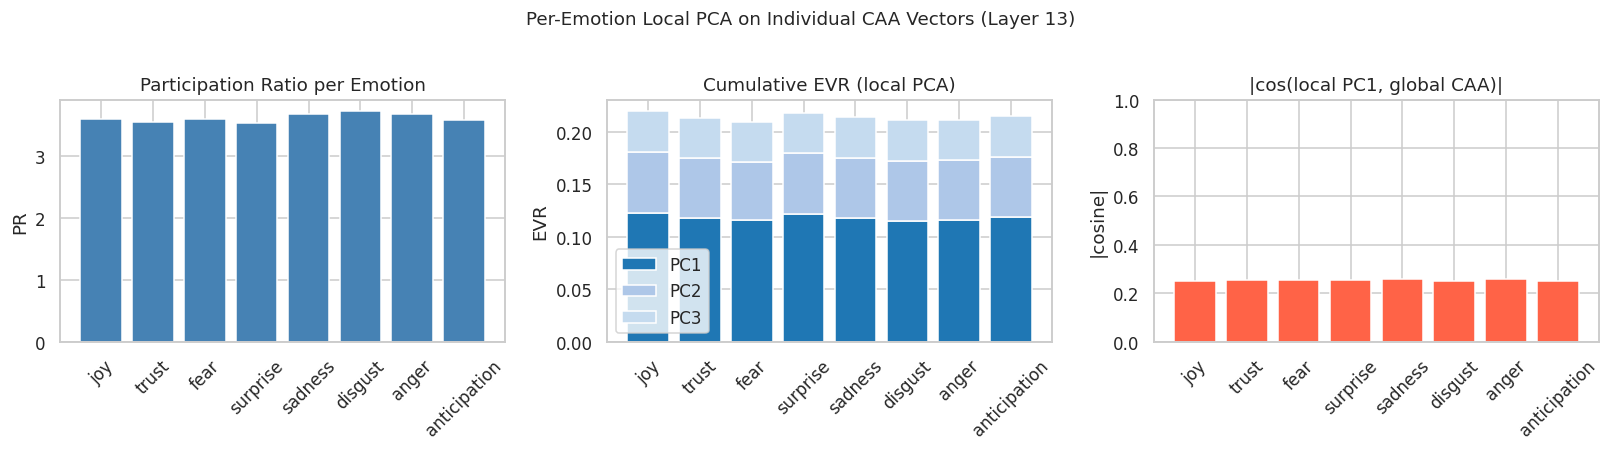

In [7]:
# Visualization: bar charts of PR and cos(PC1, globalCAA)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(df_local.index, df_local['PR'], color='steelblue')
axes[0].set_title('Participation Ratio per Emotion')
axes[0].set_ylabel('PR')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(df_local.index, df_local['EVR_PC1'], label='PC1',    color='#1f77b4')
axes[1].bar(df_local.index, df_local['EVR_PC1-2'] - df_local['EVR_PC1'],
            bottom=df_local['EVR_PC1'], label='PC2', color='#aec7e8')
axes[1].bar(df_local.index, df_local['EVR_PC1-3'] - df_local['EVR_PC1-2'],
            bottom=df_local['EVR_PC1-2'], label='PC3', color='#c5dbef')
axes[1].set_title('Cumulative EVR (local PCA)')
axes[1].set_ylabel('EVR')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(df_local.index, df_local['cos_PC1_globalCAA'], color='tomato')
axes[2].set_title('|cos(local PC1, global CAA)|')
axes[2].set_ylabel('|cosine|')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle(f'Per-Emotion Local PCA on Individual CAA Vectors (Layer {PRIMARY_LAYER})',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / f'caa_local_pca_summary_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

---
## 3. 感情「コーン」の可視化 — 個別CAAの2D散布図

グローバルCAA基底（全8感情のPCA空間）に個別CAAを射影し、
各感情が空間内でどのような「コーン」を形成するかを可視化する。

- **細いコーン** (小さな広がり): 感情は安定した方向を持つ
- **広いコーン / 重複**: 感情は隣接感情と混合する → 連続体の証拠

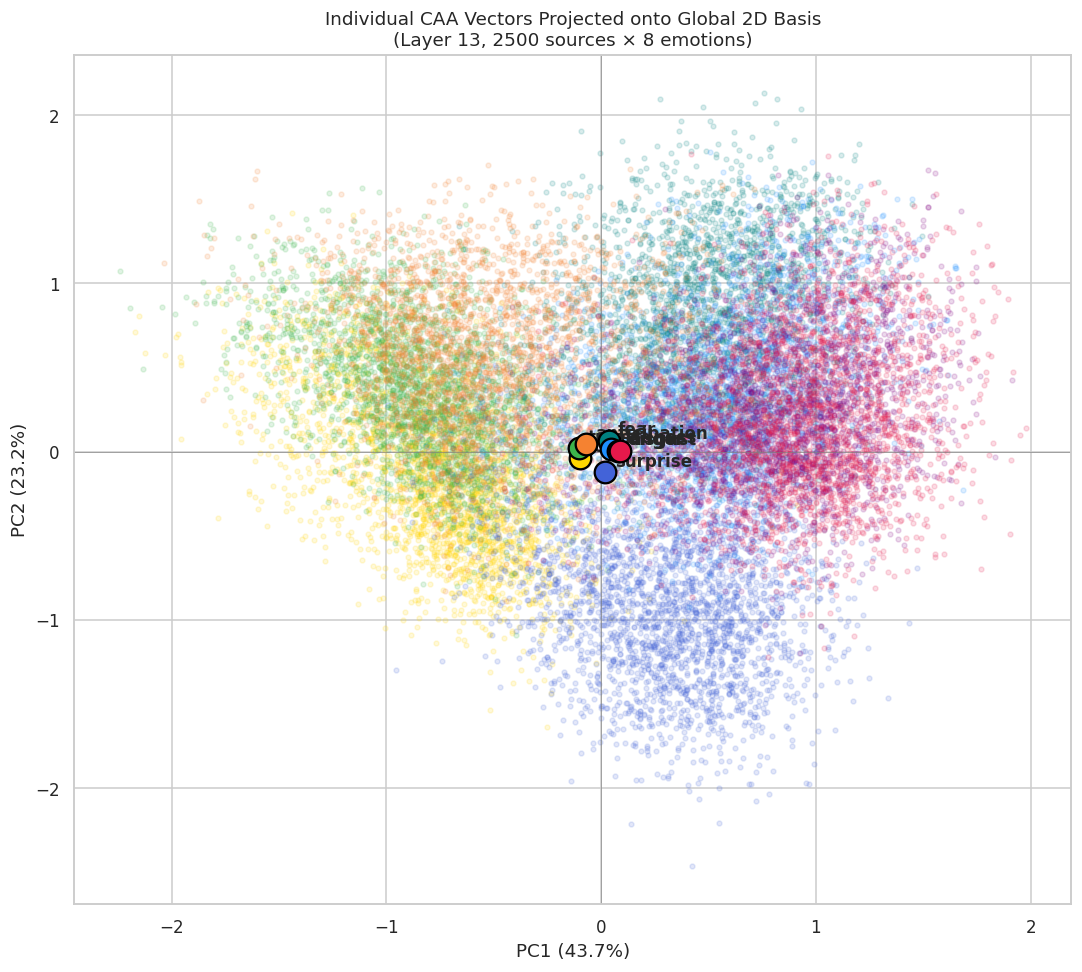

In [8]:
# Build global 2D basis from the 8 global CAA directions
pca_global = PCA(n_components=2)
pca_global.fit(global_caa)  # (8, D)
evr_g = pca_global.explained_variance_ratio_

# Project individual CAA vectors onto global PC1-PC2
# delta_pooled: (N_SUB, 8, D)
delta_flat = delta_pooled.reshape(-1, D)  # (N_SUB*8, D)
proj_flat  = pca_global.transform(delta_flat)       # (N_SUB*8, 2)
proj       = proj_flat.reshape(N_SUB, N_EMO, 2)     # (N_SUB, 8, 2)

# Also project global CAA centroids
global_proj = pca_global.transform(global_caa)  # (8, 2)

EMO_COLORS = {
    'joy': '#FFD700', 'trust': '#3cb44b', 'fear': '#008080',
    'surprise': '#4363d8', 'sadness': '#1e90ff', 'disgust': '#800080',
    'anger': '#e6194b', 'anticipation': '#f58231',
}

fig, ax = plt.subplots(figsize=(10, 9))
for e, emo in enumerate(EMOTION_ORDER):
    c = EMO_COLORS.get(emo, 'gray')
    ax.scatter(proj[:, e, 0], proj[:, e, 1],
               alpha=0.15, s=10, color=c, label=None)
    # Global centroid
    ax.scatter(global_proj[e, 0], global_proj[e, 1],
               s=200, color=c, edgecolors='black', linewidths=1.5, zorder=4)
    ax.annotate(emo, (global_proj[e, 0], global_proj[e, 1]),
                textcoords='offset points', xytext=(6, 4),
                fontsize=11, fontweight='bold')

ax.axhline(0, color='gray', linewidth=0.4)
ax.axvline(0, color='gray', linewidth=0.4)
ax.set_xlabel(f'PC1 ({evr_g[0]:.1%})')
ax.set_ylabel(f'PC2 ({evr_g[1]:.1%})')
ax.set_title(f'Individual CAA Vectors Projected onto Global 2D Basis\n'
             f'(Layer {PRIMARY_LAYER}, {N_SUB} sources × 8 emotions)')
plt.tight_layout()
plt.savefig(OUT_DIR / f'caa_cone_2d_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

---
## 4. 感情間の境界 — 個別CAAのk-NN分類精度

個別CAAベクトル `delta[n, e]` を特徴量として、感情ラベルを予測できるか？

- **高い分類精度**: 感情ごとのCAA分布は明確に分離 → 離散的境界が存在
- **低い分類精度**: 感情CAA分布が重複 → 連続的な感情空間

さらに、**全感情の低次元部分空間への射影後の精度**と比較することで、
低次元表現でどれだけ感情が区別できるかを示す。

In [9]:
# Build classification dataset: X = (N_SUB*8, D), y = emotion label
X_all = delta_pooled.reshape(-1, D)                          # (N_SUB*8, D)
y_all = np.repeat(np.arange(N_EMO), N_SUB)                   # (N_SUB*8,)
groups = np.tile(np.arange(N_SUB), N_EMO)                    # source groups

# Sort by groups for correct indexing
sort_idx = np.argsort(groups)
X_all = X_all[sort_idx]
y_all = y_all[sort_idx]
groups = groups[sort_idx]
del sort_idx   # no longer needed

# PCA projections at various dimensions
dims_to_test = [2, 4, 8, 16, 32, 64]
rows_clf = []

# GroupKFold (source-held-out)
from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=5)

for n_dims in dims_to_test:
    pca_d = PCA(n_components=n_dims, random_state=SEED)
    X_proj = pca_d.fit_transform(X_all)  # (N_SUB*8, n_dims)

    accs = []
    for train_idx, test_idx in gkf.split(X_proj, y_all, groups):
        clf = LogisticRegression(max_iter=500, C=1.0, random_state=SEED)
        clf.fit(X_proj[train_idx], y_all[train_idx])
        pred = clf.predict(X_proj[test_idx])
        accs.append(balanced_accuracy_score(y_all[test_idx], pred))
    rows_clf.append({'n_dims': n_dims, 'bal_acc': np.mean(accs), 'std': np.std(accs)})
    print(f'  n_dims={n_dims:4d}  bal_acc={np.mean(accs):.4f} ± {np.std(accs):.4f}')

df_clf = pd.DataFrame(rows_clf)
df_clf.to_csv(OUT_DIR / f'caa_emotion_separability_L{PRIMARY_LAYER}.csv', index=False)

del X_all, y_all, groups, X_proj
gc.collect()


  n_dims=   2  bal_acc=0.2569 ± 0.0029
  n_dims=   4  bal_acc=0.2691 ± 0.0038
  n_dims=   8  bal_acc=0.2810 ± 0.0057
  n_dims=  16  bal_acc=0.3044 ± 0.0029
  n_dims=  32  bal_acc=0.3337 ± 0.0035
  n_dims=  64  bal_acc=0.3629 ± 0.0019


1735

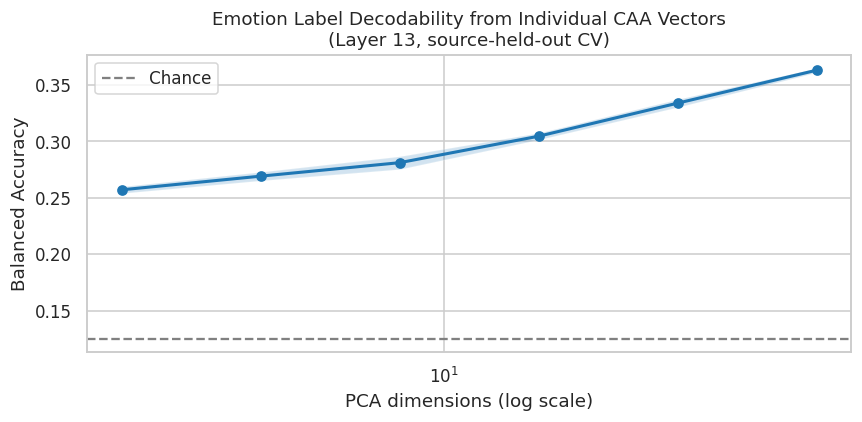

Done. Outputs saved to /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/per_source_structure


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_clf['n_dims'], df_clf['bal_acc'], marker='o', linewidth=2)
ax.fill_between(df_clf['n_dims'],
                df_clf['bal_acc'] - df_clf['std'],
                df_clf['bal_acc'] + df_clf['std'],
                alpha=0.2)
ax.axhline(1/N_EMO, color='gray', linestyle='--', label='Chance')
ax.set_xscale('log')
ax.set_xlabel('PCA dimensions (log scale)')
ax.set_ylabel('Balanced Accuracy')
ax.set_title(f'Emotion Label Decodability from Individual CAA Vectors\n'
             f'(Layer {PRIMARY_LAYER}, source-held-out CV)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f'caa_emotion_separability_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

print('Done. Outputs saved to', OUT_DIR)

---
## 5. レイヤー別の感情方向一貫性の変化

感情方向の一貫性（個別CAA ↔ グローバルCAA のコサイン類似度）が、
レイヤーを通じてどのように変化するかを追跡する。

「感情方向が形成されるレイヤー」を特定することができる。

In [11]:
# delta_pooled (primary layer) is no longer needed from here on;
# release it before the per-layer loop to free ~312 MB.
del delta_pooled
gc.collect()

rows_layer = []
for layer in LAYER_INDICES:
    print(f'  Processing layer {layer} ...')
    g_caa    = CAA_POOLED[:, LI_MAP[layer], :]         # (8, D) unit-normed
    dp       = load_per_source_caa(layer, pool_intensity=True)  # (N_SUB, 8, D)
    dp_u     = unit(dp)                                 # (N_SUB, 8, D)
    cos      = np.einsum('ned,ed->ne', dp_u, g_caa)     # (N_SUB, 8)
    del dp, dp_u
    gc.collect()
    for e, emo in enumerate(EMOTION_ORDER):
        rows_layer.append({
            'layer': layer, 'emotion': emo,
            'mean_cos': float(cos[:, e].mean()),
            'std_cos':  float(cos[:, e].std()),
        })

df_layer = pd.DataFrame(rows_layer)
df_layer.to_csv(OUT_DIR / 'caa_consistency_by_layer.csv', index=False)
print('Done loading all layers.')


  Processing layer 8 ...
  Processing layer 10 ...
  Processing layer 13 ...
  Processing layer 16 ...
  Processing layer 19 ...
  Processing layer 22 ...
Done loading all layers.


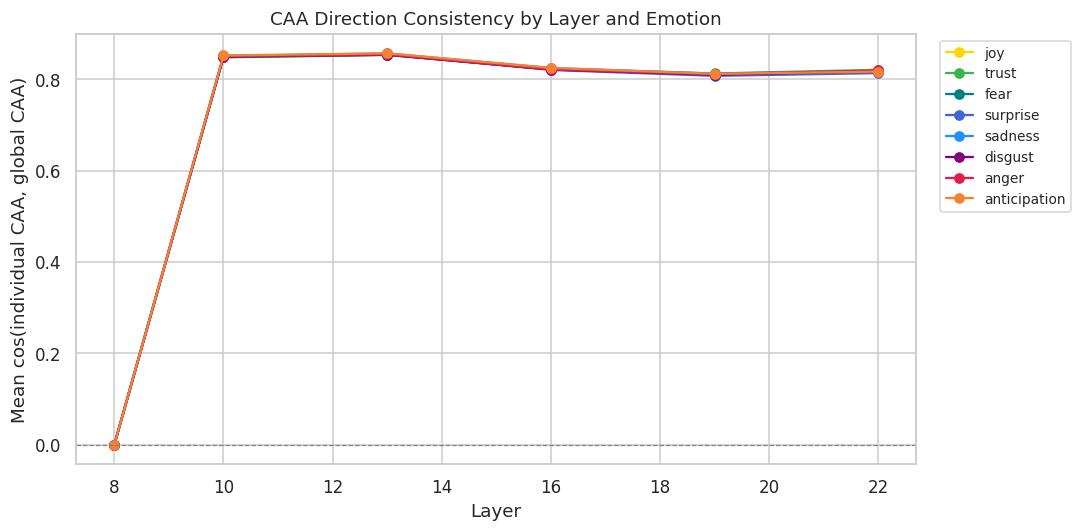

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

EMO_COLORS_LIST = [
    '#FFD700', '#3cb44b', '#008080', '#4363d8',
    '#1e90ff', '#800080', '#e6194b', '#f58231',
]

for e, emo in enumerate(EMOTION_ORDER):
    sub = df_layer[df_layer['emotion'] == emo]
    ax.plot(sub['layer'], sub['mean_cos'],
            marker='o', label=emo, color=EMO_COLORS_LIST[e], linewidth=1.5)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Layer')
ax.set_ylabel('Mean cos(individual CAA, global CAA)')
ax.set_title('CAA Direction Consistency by Layer and Emotion')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'caa_consistency_by_layer.png', bbox_inches='tight')
plt.show()